## Modelling of impact: Rolling 120 hour energy shift heuristic

The previous sections established two things that are needed before impact can be measured. First, the dashboard turns the forecast into household-facing recommendations. Second, the XGBoost model provides the hourly 120-hour price outlook that tells the heuristic when it is attractive to wait and when it is better to consume now.

This section connects those two pieces to the resilience question. The goal is to estimate whether forecast-guided shifting changes the timing of household demand enough to reduce pressure in stressed hours, not just whether it saves money for one household. In other words, the end goal is to translate the forecast into a system-impact estimate.

### Energy shift heuristic

The heuristic starts from the hourly system load and splits out the household share. Inside that household block, the model works with four behavioral segments: inflexible demand, wet loads, thermal demand, and EV charging. Each flexible segment has its own share of household load, its own maximum shiftable share, and its own waiting limit.

For every issue time, the model looks ahead 120 hours. Hour by hour, it compares the current hour with future candidate hours inside the segment's allowed waiting window. Candidate hours with lower predicted prices receive a better score, while longer waiting times are penalized. A shift is only accepted if the target hour improves the score and if the move stays within the segment's historical capacity in the receiving hour.

The heuristic therefore does not assume perfect flexibility. It keeps part of each segment fixed, limits how much energy can be moved, and prevents the simulation from pushing too much demand into one cheap hour.

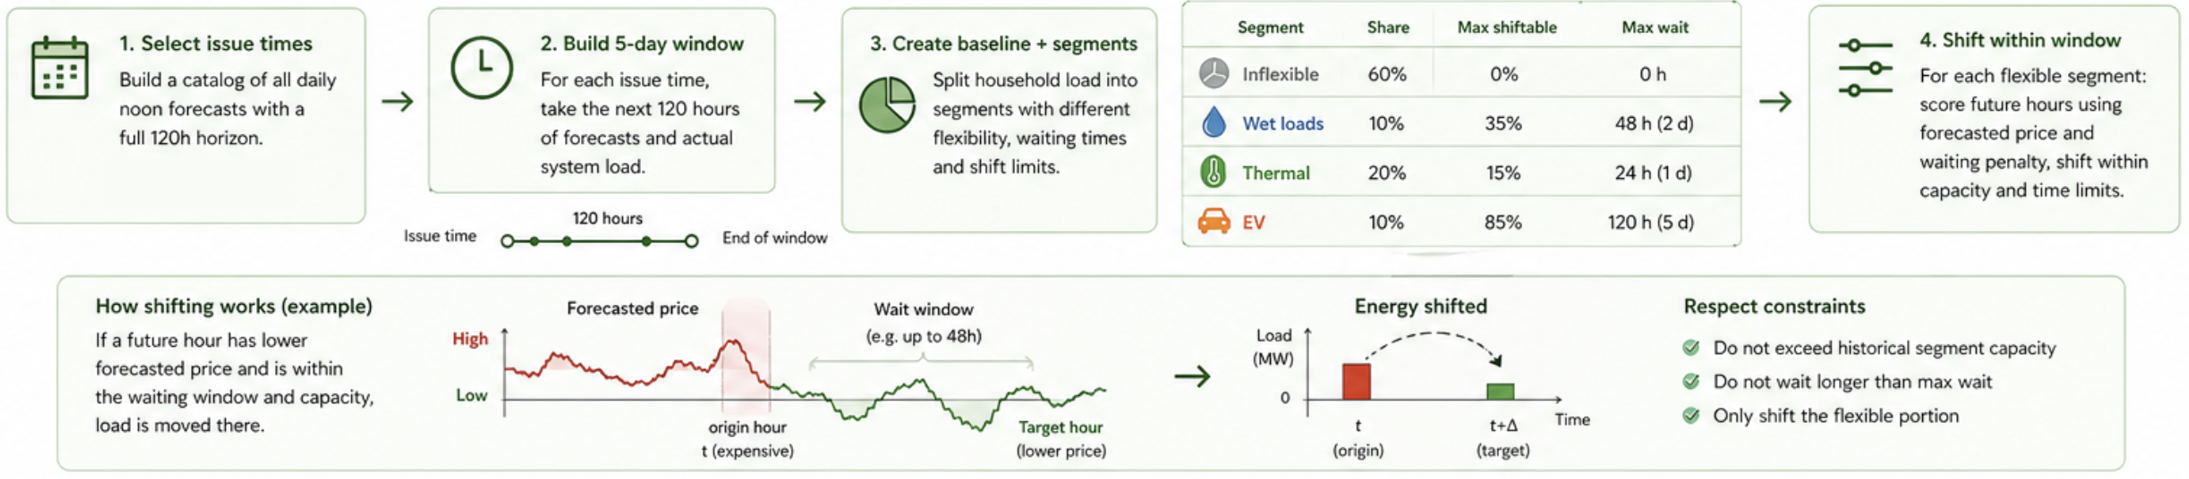

### 90-day simulation of shifted consumption

After the heuristic is defined, we simulate its effect hour for hour. For each selected issue time, the model decides what flexible energy to keep, what to move out of the current hour, and where to place it within the next 120 hours. The outputs are shifted household load, shifted system load, realized energy movement, and cost-based summary metrics.

To keep the impact section aligned with the forecasting evaluation, the simulation is run over the last 90 days. This is the same time span used as the final forecast test period. Because each forecast covers five days, we use non-overlapping 120-hour windows so that the 90-day impact estimate is not double-counting the same hours.

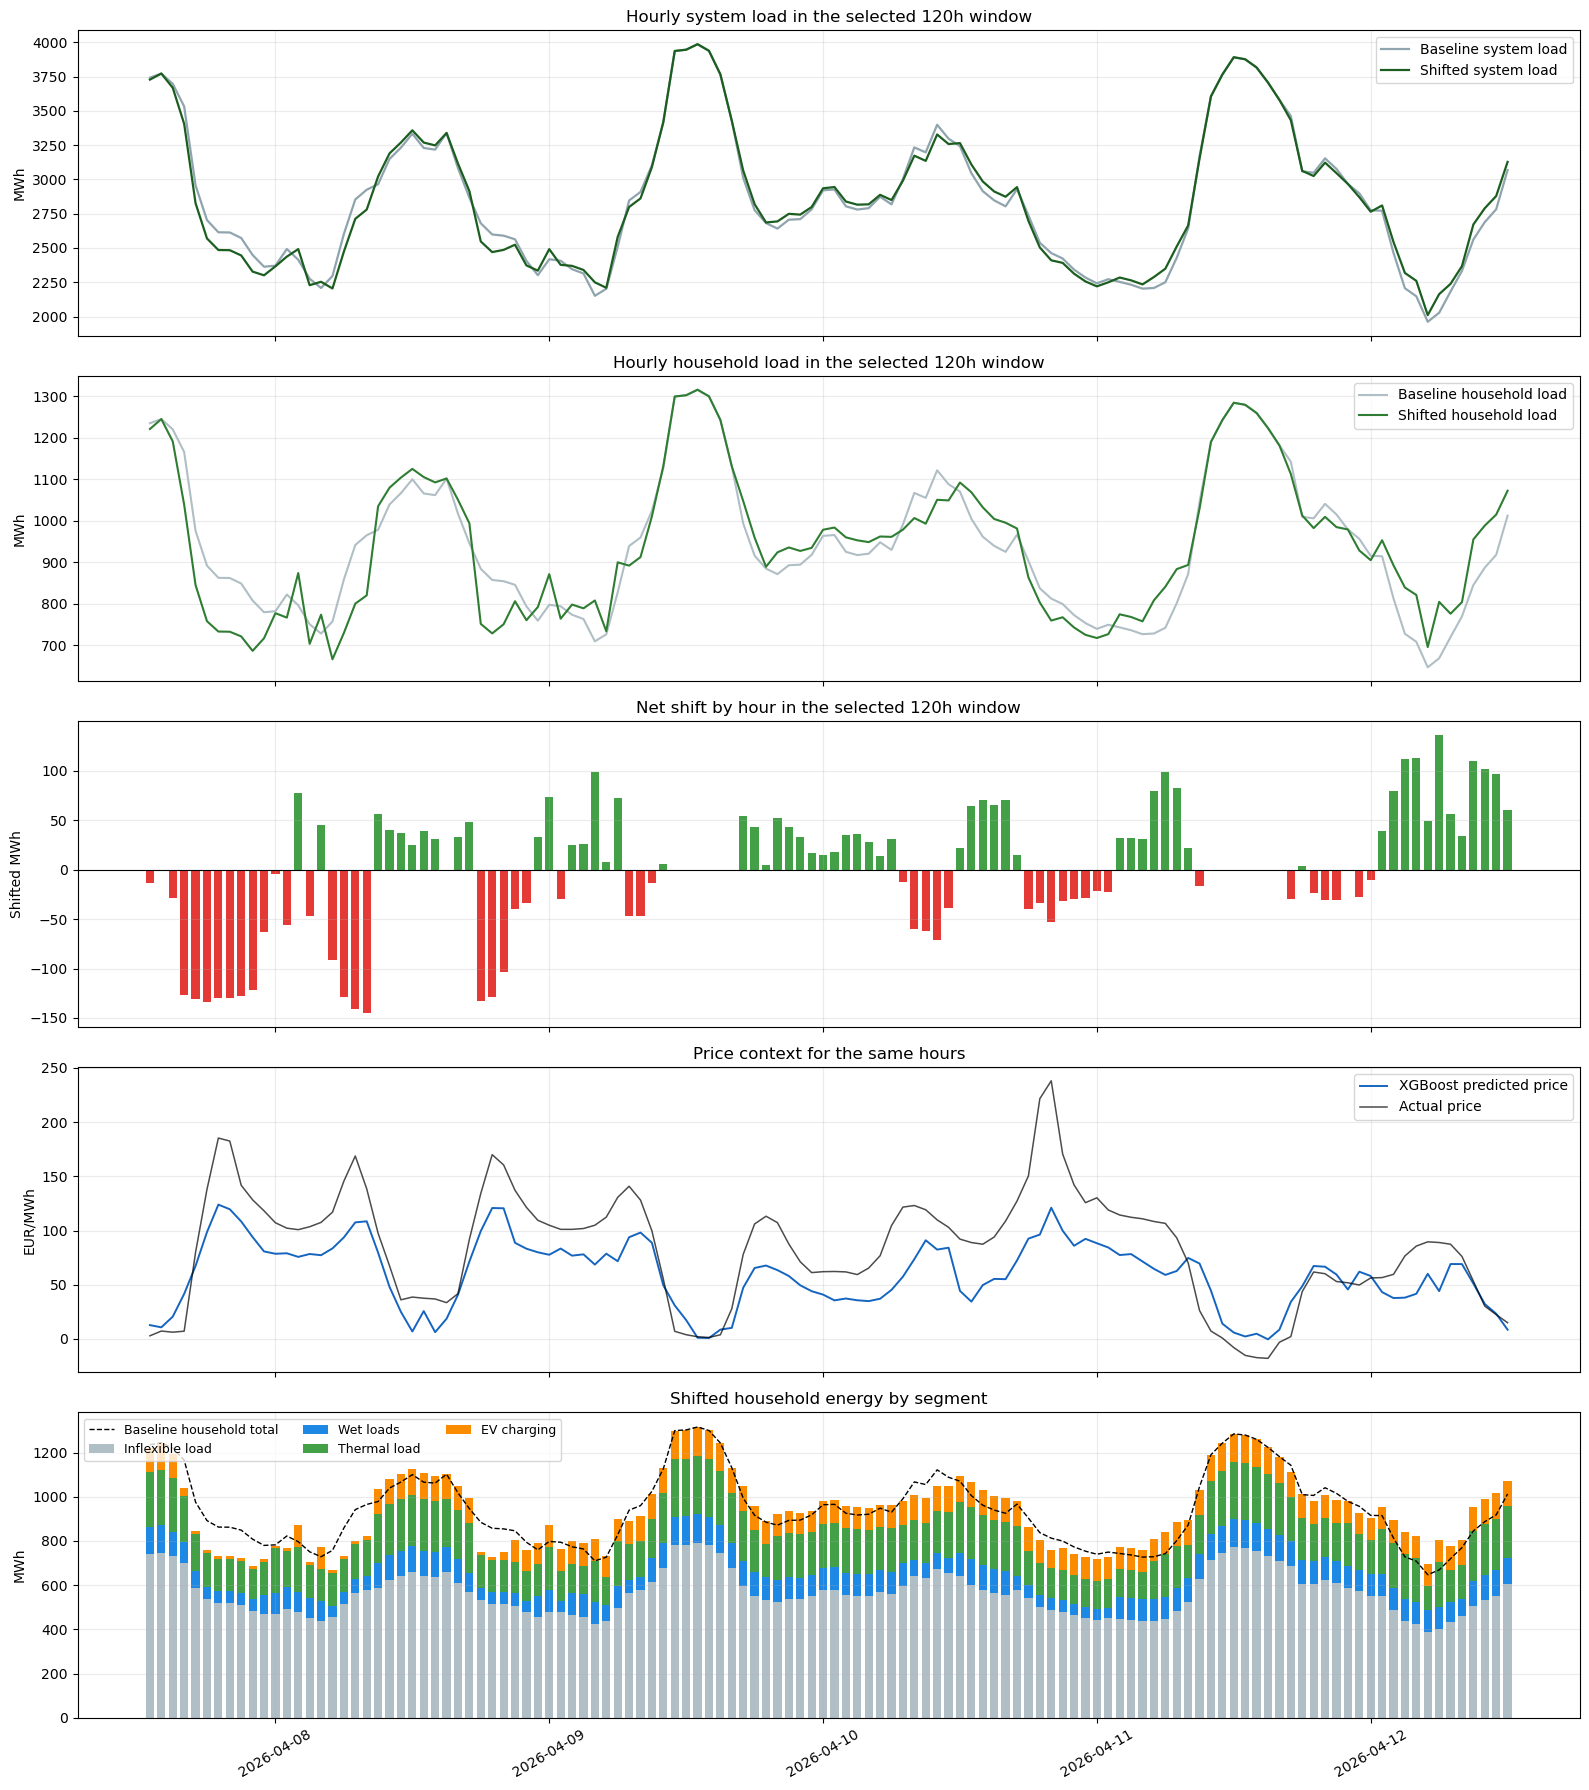

In [5]:
from src.analysis.impact_analysis import run_granular_shift_illustration

granular_result = run_granular_shift_illustration()
# display(granular_result["summary"].to_frame("value"))

The five-panel illustration above shows one 120-hour decision window in detail, but we also need to know whether the same pattern repeats across the evaluation period. The next figure aggregates the 90-day simulation into an average net-shift heatmap by hour of day and day of week.

Negative values indicate hours where load is typically moved away from the original slot, while positive values indicate hours that tend to receive shifted demand.

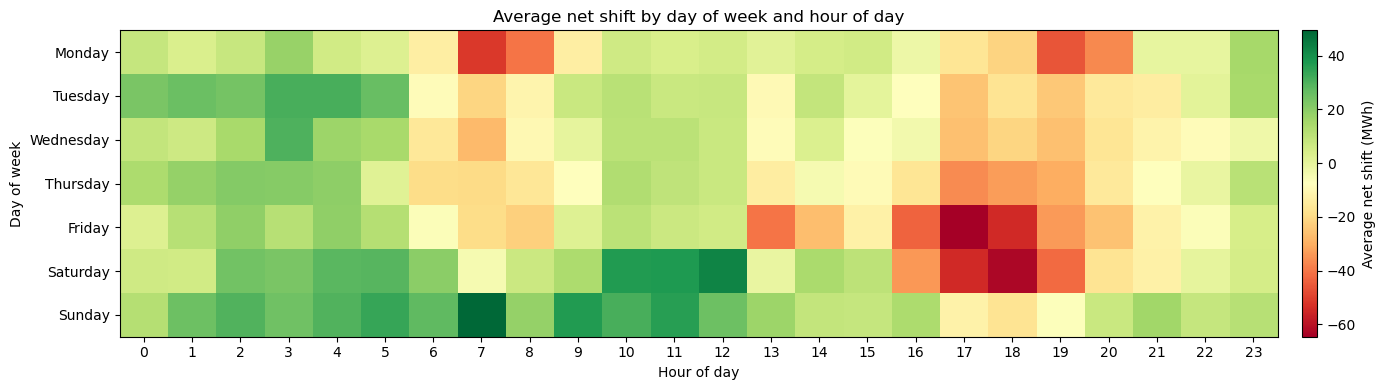

In [6]:
from src.analysis.impact_analysis import (
    plot_average_net_shift_heatmap,
    run_90_day_impact_simulation,
)

impact_90d = run_90_day_impact_simulation(simulation_days=90)
# display(impact_90d["summary"].to_frame("value"))
heatmap_df, _, _ = plot_average_net_shift_heatmap(impact_90d["profiles"])
# display(heatmap_df.round(2))

The heatmap shows whether the heuristic creates a stable timing pattern rather than isolated shifts. If the same hours repeatedly lose demand while other hours repeatedly absorb it, the heuristic is not just reacting to one unusual week. It is creating a repeatable temporal redistribution of demand.

The last figure in this section turns that timing pattern into a peak-impact measure. The waterfall compares cumulative load above the historical p95 threshold before and after shifting, both for total household demand and for the full system load.

,baseline_p95_mwh,current_above_p95_mwh,impact_mwh,shifted_above_p95_mwh,peak_reduction_pct,current_hours_above_p95,shifted_hours_above_p95
case,,,,,,,
Total household,1101.47,86932.71,2614.02,84318.69,3.01,877,873
Total system energy,3337.78,263432.46,3887.42,259545.03,1.48,877,875


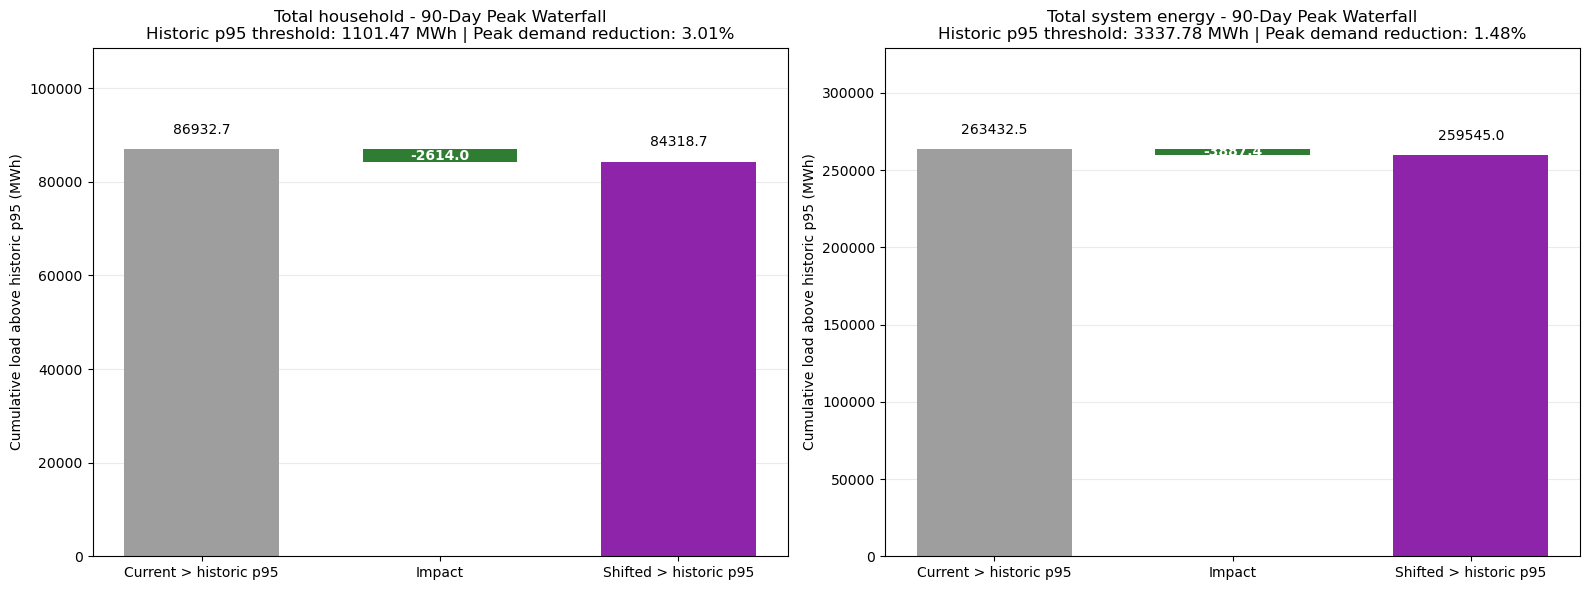

In [3]:
from src.analysis.impact_analysis import plot_peak_excess_waterfalls

peak_summary_df, _, _ = plot_peak_excess_waterfalls(
    impact_90d["profiles"],
    impact_90d["system_load"],
)
display(
    peak_summary_df.assign(
        baseline_p95_mwh=lambda df: df["baseline_p95_mwh"].round(2),
        current_above_p95_mwh=lambda df: df["current_above_p95_mwh"].round(2),
        impact_mwh=lambda df: df["impact_mwh"].round(2),
        shifted_above_p95_mwh=lambda df: df["shifted_above_p95_mwh"].round(2),
        peak_reduction_pct=lambda df: df["peak_reduction_pct"].round(2),
    ).set_index("case")
)

### Assumptions behind the heuristic

The impact model rests on a small set of transparent assumptions. The most important are the estimated household share of total system demand, the segment split inside household demand, the maximum shiftable share in each segment, and the allowed waiting time before the energy service must still be delivered.

These are scenario choices rather than measured behavioral truths. They define what the heuristic is allowed to move. The table below therefore should be read as the behavioral boundary of the simulation: if the shiftable shares or waiting windows change, the estimated impact changes as well.

In [4]:
from src.analysis.impact_analysis import (
    make_heuristic_assumption_summary,
    make_heuristic_assumption_table,
)

assumption_summary = make_heuristic_assumption_summary()
assumption_table = make_heuristic_assumption_table()

display(assumption_summary.to_frame("value"))
display(assumption_table.round(2))

,value
household_share_of_system_pct,33.00
flexible_share_of_household_pct,40.00
max_theoretical_shiftable_share_of_household_pct,15.00
max_theoretical_shiftable_share_of_system_pct,4.95


,segment,label,share_of_household_load_pct,max_shiftable_share_pct,max_shiftable_share_of_household_pct,max_wait_h,wait_penalty
0,inflexible,Inflexible load,60.0,0.0,0.0,0,0.00
1,wet_loads,Wet loads,10.0,35.0,3.5,48,0.90
2,thermal,Thermal load,20.0,15.0,3.0,24,1.20
3,ev,EV charging,10.0,85.0,8.5,120,0.35
